In [15]:
import pandas as pd
import json
import glob
from pathlib import Path
from collections import defaultdict
import numpy as np
from datetime import datetime

def load_logs_to_dataframe(log_files):
    """加载所有日志文件到DataFrame"""
    all_data = []
    
    for log_file in log_files:
        with open(log_file, 'r') as f:
            for line in f:
                if line.strip():
                    try:
                        data = json.loads(line.strip())
                        all_data.append(data)
                    except json.JSONDecodeError:
                        print(f"Warning: Invalid JSON in {log_file}: {line}")
                        continue
    
    return pd.DataFrame(all_data)

def create_stage_timeline_df(df):
    """创建每个request_id的阶段时间线DataFrame"""
    
    # 按request_id分组，收集所有事件
    grouped = df.groupby('request_id')
    
    timeline_data = []
    
    for request_id, group in grouped:
        # 为每个request_id创建一行数据
        row_data = {'request_id': request_id}
        
        # 按时间戳排序事件
        sorted_events = group.sort_values('timestamp')
        
        # 记录每个事件的ISO时间戳
        for _, event in sorted_events.iterrows():
            event_name = event['event_name']
            # 只为每个事件创建ISO时间戳列
            row_data[f'{event_name}_timestamp_iso'] = event['timestamp_iso']
        
        timeline_data.append(row_data)
    
    return pd.DataFrame(timeline_data)

def get_df(path):
    # 使用示例
    # 找到所有日志文件
    log_files = glob.glob(path)  # 根据你的实际路径调整

    # 加载数据
    df = load_logs_to_dataframe(log_files)
    print(f"原始数据行数: {len(df)}")
    print(f"唯一request_id数量: {df['request_id'].nunique()}")

    # 过滤掉request_id为0的数据
    df = df[df['request_id'] != 0]
    print(f"过滤后数据行数: {len(df)}")
    print(f"过滤后唯一request_id数量: {df['request_id'].nunique()}")

    # 创建时间线DataFrame
    timeline_df = create_stage_timeline_df(df)
    return timeline_df

def merge_timeline_df(timeline_df_a, timeline_df_b):
    """修复后的合并函数"""
    # 分别过滤两个DataFrame
    df_a_filtered = timeline_df_a[timeline_df_a["request_id"] != "None"]
    df_b_filtered = timeline_df_b[timeline_df_b["request_id"] != "None"]
    
    # 合并A表和B表
    timeline_df = df_a_filtered.merge(df_b_filtered, on="request_id", how="left")
    return timeline_df

timeline_df_a = get_df("/sgl-workspace/sglang/events_log_*")
timeline_df_b = get_df("/sgl-workspace/sglang/events/events_log_*")
timeline_df = merge_timeline_df(timeline_df_a, timeline_df_b)


原始数据行数: 50325
唯一request_id数量: 10010
过滤后数据行数: 50121
过滤后唯一request_id数量: 10009
原始数据行数: 60169
唯一request_id数量: 10008
过滤后数据行数: 60105
过滤后唯一request_id数量: 10007


In [17]:
timeline_df_a.columns.tolist()

['request_id',
 'init_recv_ack_timestamp_iso',
 'prefill_bootstrap_queue_add_timestamp_iso',
 'PREFILL_BOOTSTRAP_timestamp_iso',
 'PREFILL_FORWARD_timestamp_iso',
 'PREFILL_TRANSFER_KV_CACHE_timestamp_iso',
 'register_kv_args_ack_timestamp_iso']

In [18]:
timeline_df_b.columns.tolist()

['request_id',
 'DECODE_PREPARE_timestamp_iso',
 'init_recv_timestamp_iso',
 'DECODE_PREALLOC_timestamp_iso',
 'recv_kv_cache_timestamp_iso',
 'DECODE_TRANSFERRED_timestamp_iso',
 'DECODE_WAITING_timestamp_iso',
 'register_kv_args_timestamp_iso']

In [45]:
#把所有时间戳列转换为datetime类型,request_id字段保留为int类型
timeline_df = timeline_df.astype({"request_id": "int"})
timeline_df = timeline_df.apply(lambda x: pd.to_datetime(x) if x.dtype == "object" else x)
timeline_df.dtypes
#把所有时间戳列转换为datetime类型
timeline_df = timeline_df.apply(lambda x: pd.to_datetime(x) if x.dtype == "object" else x)
timeline_df.dtypes


request_id                                            int64
init_recv_ack_timestamp_iso                  datetime64[ns]
prefill_bootstrap_queue_add_timestamp_iso    datetime64[ns]
PREFILL_BOOTSTRAP_timestamp_iso              datetime64[ns]
PREFILL_FORWARD_timestamp_iso                datetime64[ns]
PREFILL_TRANSFER_KV_CACHE_timestamp_iso      datetime64[ns]
register_kv_args_ack_timestamp_iso           datetime64[ns]
DECODE_PREPARE_timestamp_iso                 datetime64[ns]
init_recv_timestamp_iso                      datetime64[ns]
DECODE_PREALLOC_timestamp_iso                datetime64[ns]
recv_kv_cache_timestamp_iso                  datetime64[ns]
DECODE_TRANSFERRED_timestamp_iso             datetime64[ns]
DECODE_WAITING_timestamp_iso                 datetime64[ns]
register_kv_args_timestamp_iso               datetime64[ns]
dtype: object

In [55]:
summary_df = pd.DataFrame()

# init_recv_ack_timestamp_iso-init_recv_timestamp_iso
summary_df["request_id"] = timeline_df["request_id"]
# 计算时间差并转换为毫秒
def f(field1, field2,target_field):
    time_diff = timeline_df[field1] - timeline_df[field2]
    summary_df[target_field] = time_diff.dt.total_seconds() * 1000
    

f("PREFILL_BOOTSTRAP_timestamp_iso","prefill_bootstrap_queue_add_timestamp_iso","bootstrap_ms")
f("init_recv_ack_timestamp_iso","init_recv_timestamp_iso","prealloc_notify_p_ms")
f("PREFILL_TRANSFER_KV_CACHE_timestamp_iso","PREFILL_FORWARD_timestamp_iso","transfer_kv_cache_ms")
f("DECODE_PREALLOC_timestamp_iso","DECODE_PREPARE_timestamp_iso","pre_alloc_ms")
f("recv_kv_cache_timestamp_iso","DECODE_PREALLOC_timestamp_iso","decode_transferred_ms")
f("DECODE_WAITING_timestamp_iso","recv_kv_cache_timestamp_iso","decode_waiting_ms")


In [64]:
summary_df.columns.tolist()

['request_id',
 'bootstrap_ms',
 'prealloc_notify_p_ms',
 'transfer_kv_cache_ms',
 'pre_alloc_ms',
 'decode_transferred_ms',
 'decode_waiting_ms']

bootstrap_ms: Mean=5.03ms, Median=0.43ms, Std=27.91ms
prealloc_notify_p_ms: Mean=21.51ms, Median=13.25ms, Std=76.49ms
transfer_kv_cache_ms: Mean=144.90ms, Median=146.00ms, Std=49.12ms
pre_alloc_ms: Mean=0.53ms, Median=0.52ms, Std=0.07ms
decode_transferred_ms: Mean=743.39ms, Median=612.67ms, Std=421.34ms
decode_waiting_ms: Mean=5.90ms, Median=5.69ms, Std=3.41ms


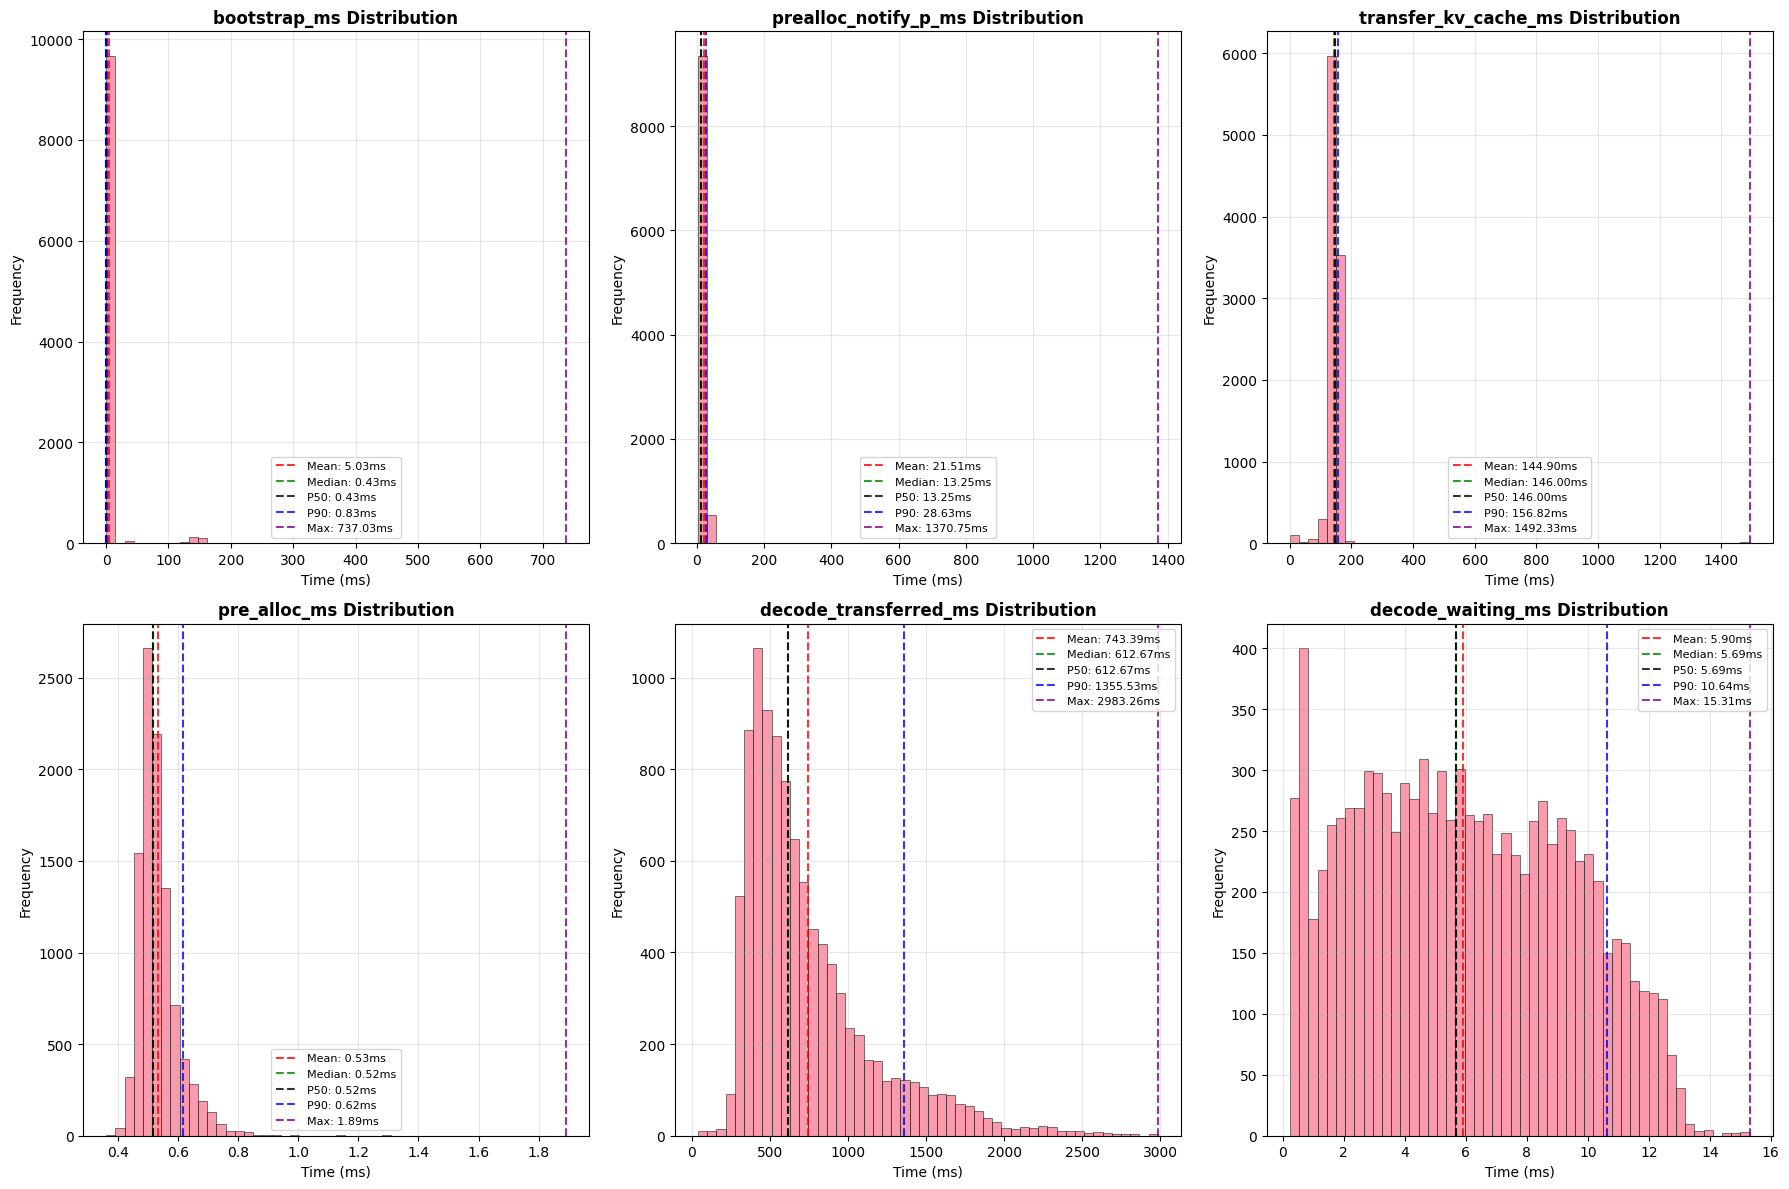

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图样式
plt.style.use('default')
sns.set_palette("husl")

# 要绘制的列
columns_to_plot = summary_df.columns.tolist()

# 创建子图
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# 为每个列绘制直方图
for i, col in enumerate(columns_to_plot):
    if col in summary_df.columns:
        # 过滤掉NaN值
        data = summary_df[col].dropna()
        
        # 绘制直方图
        axes[i].hist(data, bins=50, alpha=0.7, edgecolor='black', linewidth=0.5)
        axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Time (ms)', fontsize=10)
        axes[i].set_ylabel('Frequency', fontsize=10)
        axes[i].grid(True, alpha=0.3)
        
        # 添加统计信息
        mean_val = data.mean()
        median_val = data.median()
        axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2f}ms')
        axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.8, label=f'Median: {median_val:.2f}ms')
        axes[i].axvline(data.quantile(0.5), color='black', linestyle='--', alpha=0.8, label=f'P50: {data.quantile(0.5):.2f}ms')
        axes[i].axvline(data.quantile(0.9), color='blue', linestyle='--', alpha=0.8, label=f'P90: {data.quantile(0.9):.2f}ms')
        axes[i].axvline(data.max(), color='purple', linestyle='--', alpha=0.8, label=f'Max: {data.max():.2f}ms')
        axes[i].legend(fontsize=8)
        
        print(f"{col}: Mean={mean_val:.2f}ms, Median={median_val:.2f}ms, Std={data.std():.2f}ms")

plt.tight_layout()
plt.show()


/tmp/ipykernel_438173/1339943975.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)


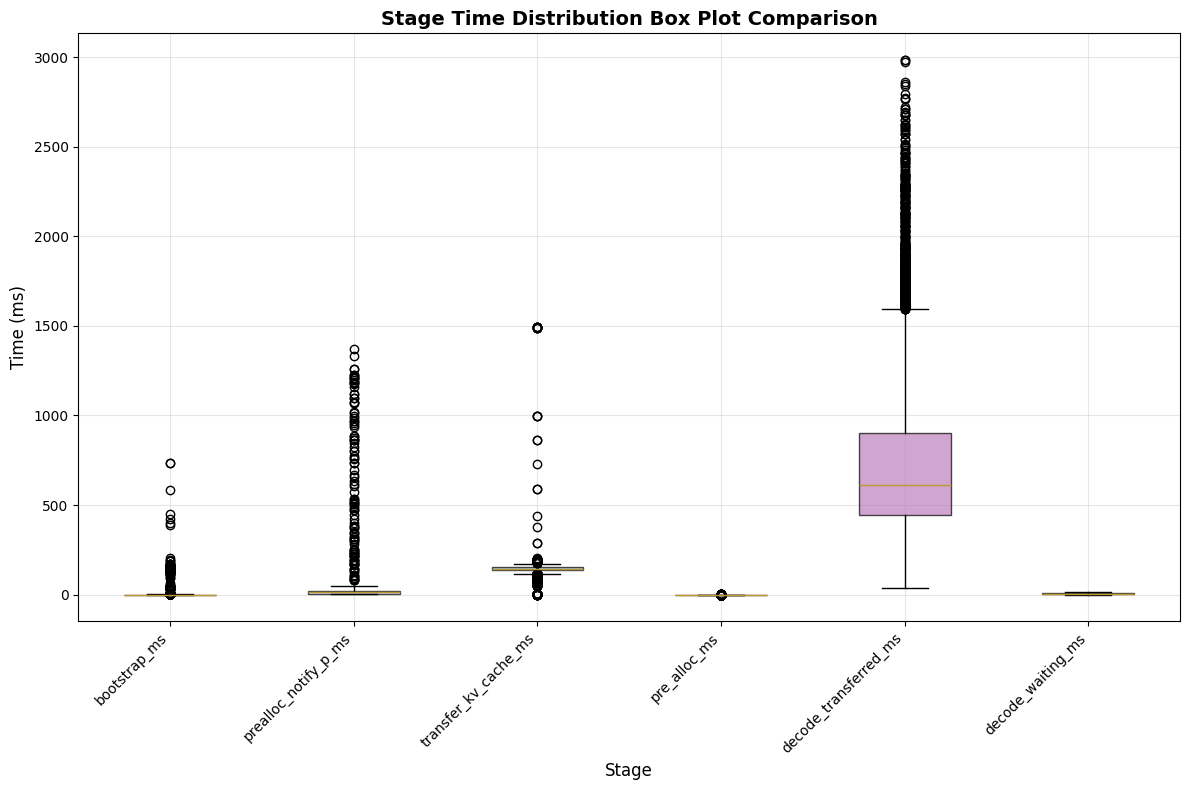


Detailed Statistics:

bootstrap_ms:
  Data Points: 10007
  Mean: 5.034 ms
  Median: 0.434 ms
  Std Dev: 27.913 ms
  Min: 0.139 ms
  Max: 737.027 ms
  25th Percentile: 0.326 ms
  75th Percentile: 0.592 ms

prealloc_notify_p_ms:
  Data Points: 10000
  Mean: 21.511 ms
  Median: 13.255 ms
  Std Dev: 76.488 ms
  Min: 3.788 ms
  Max: 1370.755 ms
  25th Percentile: 4.530 ms
  75th Percentile: 22.780 ms

transfer_kv_cache_ms:
  Data Points: 10007
  Mean: 144.897 ms
  Median: 145.995 ms
  Std Dev: 49.115 ms
  Min: 0.558 ms
  Max: 1492.331 ms
  25th Percentile: 138.690 ms
  75th Percentile: 152.754 ms

pre_alloc_ms:
  Data Points: 10007
  Mean: 0.534 ms
  Median: 0.518 ms
  Std Dev: 0.075 ms
  Min: 0.361 ms
  Max: 1.890 ms
  25th Percentile: 0.490 ms
  75th Percentile: 0.560 ms

decode_transferred_ms:
  Data Points: 10000
  Mean: 743.386 ms
  Median: 612.666 ms
  Std Dev: 421.344 ms
  Min: 38.951 ms
  Max: 2983.258 ms
  25th Percentile: 445.086 ms
  75th Percentile: 903.884 ms

decode_waiting_m

In [70]:
# 创建箱线图进行对比
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# 准备数据用于箱线图
box_data = []
box_labels = []

for col in columns_to_plot:
    if col in summary_df.columns:
        data = summary_df[col].dropna()
        box_data.append(data)
        box_labels.append(col)

# 绘制箱线图
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True)

# 设置颜色
colors = plt.cm.Set3(np.linspace(0, 1, len(box_data)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Stage Time Distribution Box Plot Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Time (ms)', fontsize=12)
ax.set_xlabel('Stage', fontsize=12)
ax.grid(True, alpha=0.3)

# 旋转x轴标签
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 打印详细统计信息
print("\nDetailed Statistics:")
print("=" * 80)
for col in columns_to_plot:
    if col in summary_df.columns:
        data = summary_df[col].dropna()
        print(f"\n{col}:")
        print(f"  Data Points: {len(data)}")
        print(f"  Mean: {data.mean():.3f} ms")
        print(f"  Median: {data.median():.3f} ms")
        print(f"  Std Dev: {data.std():.3f} ms")
        print(f"  Min: {data.min():.3f} ms")
        print(f"  Max: {data.max():.3f} ms")
        print(f"  25th Percentile: {data.quantile(0.25):.3f} ms")
        print(f"  75th Percentile: {data.quantile(0.75):.3f} ms")
